# Step 5 — GRU Model Evaluation

**Run this notebook in VSCode after training on Colab.**

### Steps:
1. Train on Colab using `step5_train_gru.py`
2. Download from Google Drive to `artifacts/step5_gru/`:
   - `best_model.pt`
   - `training_history.json`
   - `test_predictions.npz`
   - `test_summary.json`
3. Run this notebook top to bottom

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks','src') else Path.cwd()
STEP5_ROOT   = PROJECT_ROOT / 'artifacts' / 'step5_gru'

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Step 5 root: {STEP5_ROOT}')
print(f'Exists: {STEP5_ROOT.exists()}')

Step 5 root: c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step5_gru
Exists: True


In [2]:
summary = json.loads((STEP5_ROOT / 'test_summary.json').read_text())
history_df = pd.DataFrame(json.loads((STEP5_ROOT / 'training_history.json').read_text()))
preds = np.load(STEP5_ROOT / 'test_predictions.npz', allow_pickle=True)

pred_lat      = preds['pred_lat']
pred_lon      = preds['pred_lon']
true_lat      = preds['true_lat']
true_lon      = preds['true_lon']
baseline_lat  = preds['baseline_lat']
baseline_lon  = preds['baseline_lon']
mask          = preds['mask']
gru_errors    = preds['gru_errors_m']
baseline_errs = preds['baseline_errors_m']

N = pred_lat.shape[0]
print(f'Loaded {N} test flights')
print(json.dumps(summary, indent=2))

Loaded 240 test flights
{
  "version": "v2_with_altitude",
  "best_epoch": 29,
  "best_val_loss": 78799.75065104167,
  "test_flights": 240,
  "gru_mean_error_km": 83.37385559082031,
  "gru_median_error_km": 65.97693634033203,
  "gru_p90_error_km": 159.18557739257812,
  "baseline_mean_error_km": 149.5361785888672,
  "baseline_median_error_km": 131.0386962890625,
  "improvement_mean_pct": 44.24502182006836,
  "improvement_median_pct": 49.65079879760742,
  "altitude_rmse_ft": 443.9924011230469,
  "model_params": 693891
}


## Training curves

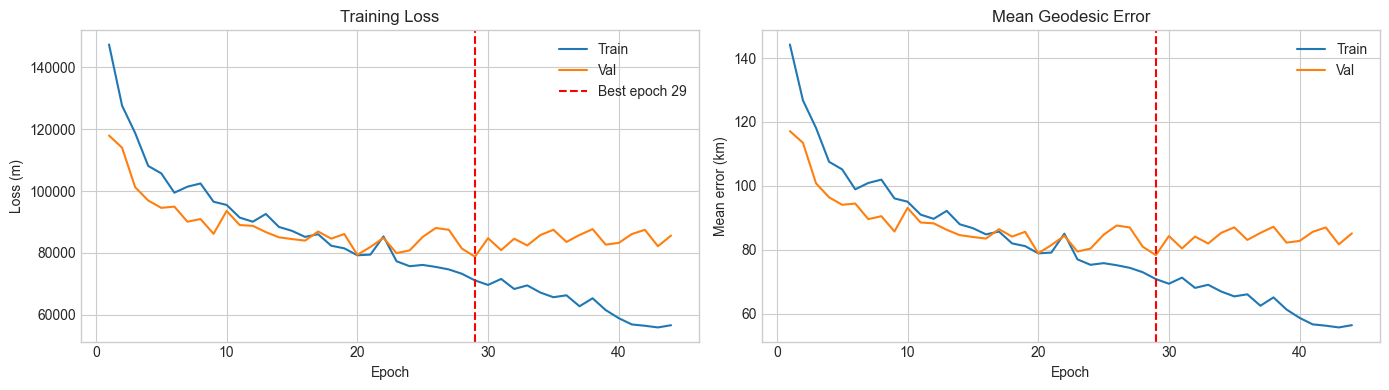

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'],   label='Val')
axes[0].axvline(summary['best_epoch'], color='red', linestyle='--',
                label=f'Best epoch {summary["best_epoch"]}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (m)')
axes[0].set_title('Training Loss'); axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_pos_m'] / 1000, label='Train')
axes[1].plot(history_df['epoch'], history_df['val_pos_m'] / 1000, label='Val')
axes[1].axvline(summary['best_epoch'], color='red', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean error (km)')
axes[1].set_title('Mean Geodesic Error'); axes[1].legend()

plt.tight_layout()
plt.savefig(STEP5_ROOT / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## GRU vs Baseline results

In [4]:
gru_pf = np.array([gru_errors[i][mask[i]>0].mean()    for i in range(N) if (mask[i]>0).sum()>0])
bl_pf  = np.array([baseline_errs[i][mask[i]>0].mean() for i in range(N) if (mask[i]>0).sum()>0])

table = pd.DataFrame({
    'Metric': ['Mean error (km)','Median error (km)','P90 error (km)','Flights'],
    'Baseline': [f'{bl_pf.mean()/1e3:.2f}', f'{np.median(bl_pf)/1e3:.2f}',
                 f'{np.percentile(bl_pf,90)/1e3:.2f}', str(len(bl_pf))],
    'GRU': [f'{gru_pf.mean()/1e3:.2f}', f'{np.median(gru_pf)/1e3:.2f}',
            f'{np.percentile(gru_pf,90)/1e3:.2f}', str(len(gru_pf))],
    'Improvement': [
        f"{(1-gru_pf.mean()/bl_pf.mean())*100:.1f}%",
        f"{(1-np.median(gru_pf)/np.median(bl_pf))*100:.1f}%",
        f"{(1-np.percentile(gru_pf,90)/np.percentile(bl_pf,90))*100:.1f}%",
        ''
    ]
})
display(table.style.hide(axis='index'))

Metric,Baseline,GRU,Improvement
Mean error (km),149.54,83.37,44.2%
Median error (km),131.04,65.98,49.7%
P90 error (km),258.50,159.19,38.4%
Flights,240,240,


## Error distribution comparison

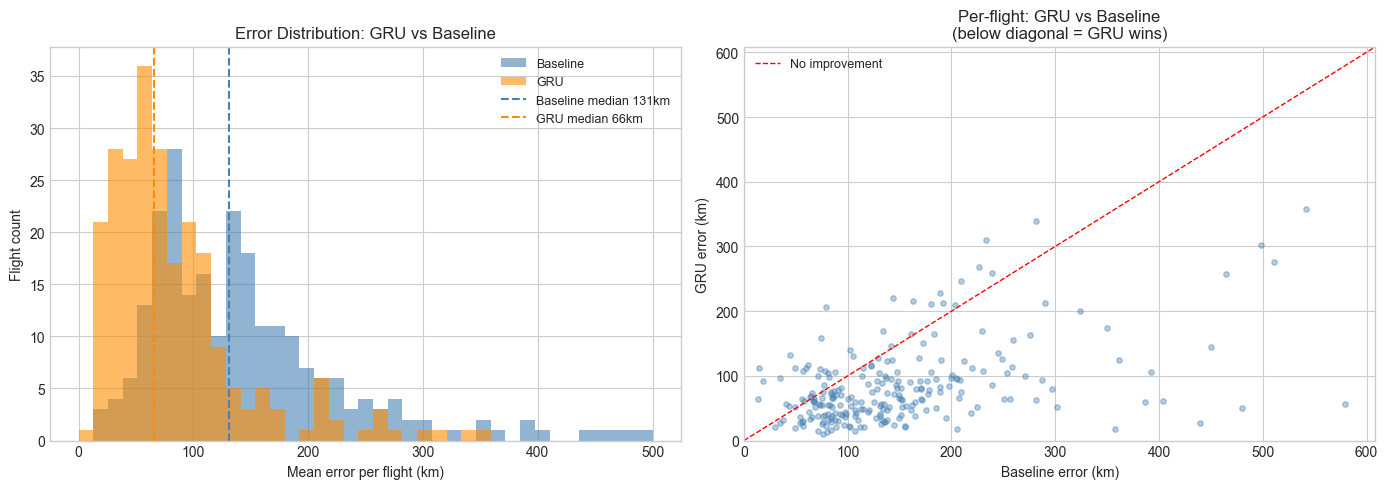

GRU beats baseline on 198/240 flights (82.5%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 500, 40)
axes[0].hist(bl_pf/1e3,  bins=bins, alpha=0.6, label='Baseline', color='steelblue')
axes[0].hist(gru_pf/1e3, bins=bins, alpha=0.6, label='GRU',      color='darkorange')
axes[0].axvline(np.median(bl_pf)/1e3,  color='steelblue',  linestyle='--',
                label=f'Baseline median {np.median(bl_pf)/1e3:.0f}km')
axes[0].axvline(np.median(gru_pf)/1e3, color='darkorange', linestyle='--',
                label=f'GRU median {np.median(gru_pf)/1e3:.0f}km')
axes[0].set_xlabel('Mean error per flight (km)')
axes[0].set_ylabel('Flight count')
axes[0].set_title('Error Distribution: GRU vs Baseline')
axes[0].legend(fontsize=9)

lim = max(bl_pf.max(), gru_pf.max()) / 1e3 * 1.05
axes[1].scatter(bl_pf/1e3, gru_pf/1e3, alpha=0.4, s=15, color='steelblue')
axes[1].plot([0,lim],[0,lim],'r--',lw=1,label='No improvement')
axes[1].set_xlabel('Baseline error (km)'); axes[1].set_ylabel('GRU error (km)')
axes[1].set_title('Per-flight: GRU vs Baseline\n(below diagonal = GRU wins)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0,lim); axes[1].set_ylim(0,lim)

plt.tight_layout()
plt.savefig(STEP5_ROOT / 'error_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

beats = (gru_pf < bl_pf).sum()
print(f'GRU beats baseline on {beats}/{len(gru_pf)} flights ({beats/len(gru_pf)*100:.1f}%)')

## Example reconstructions (4 flights)

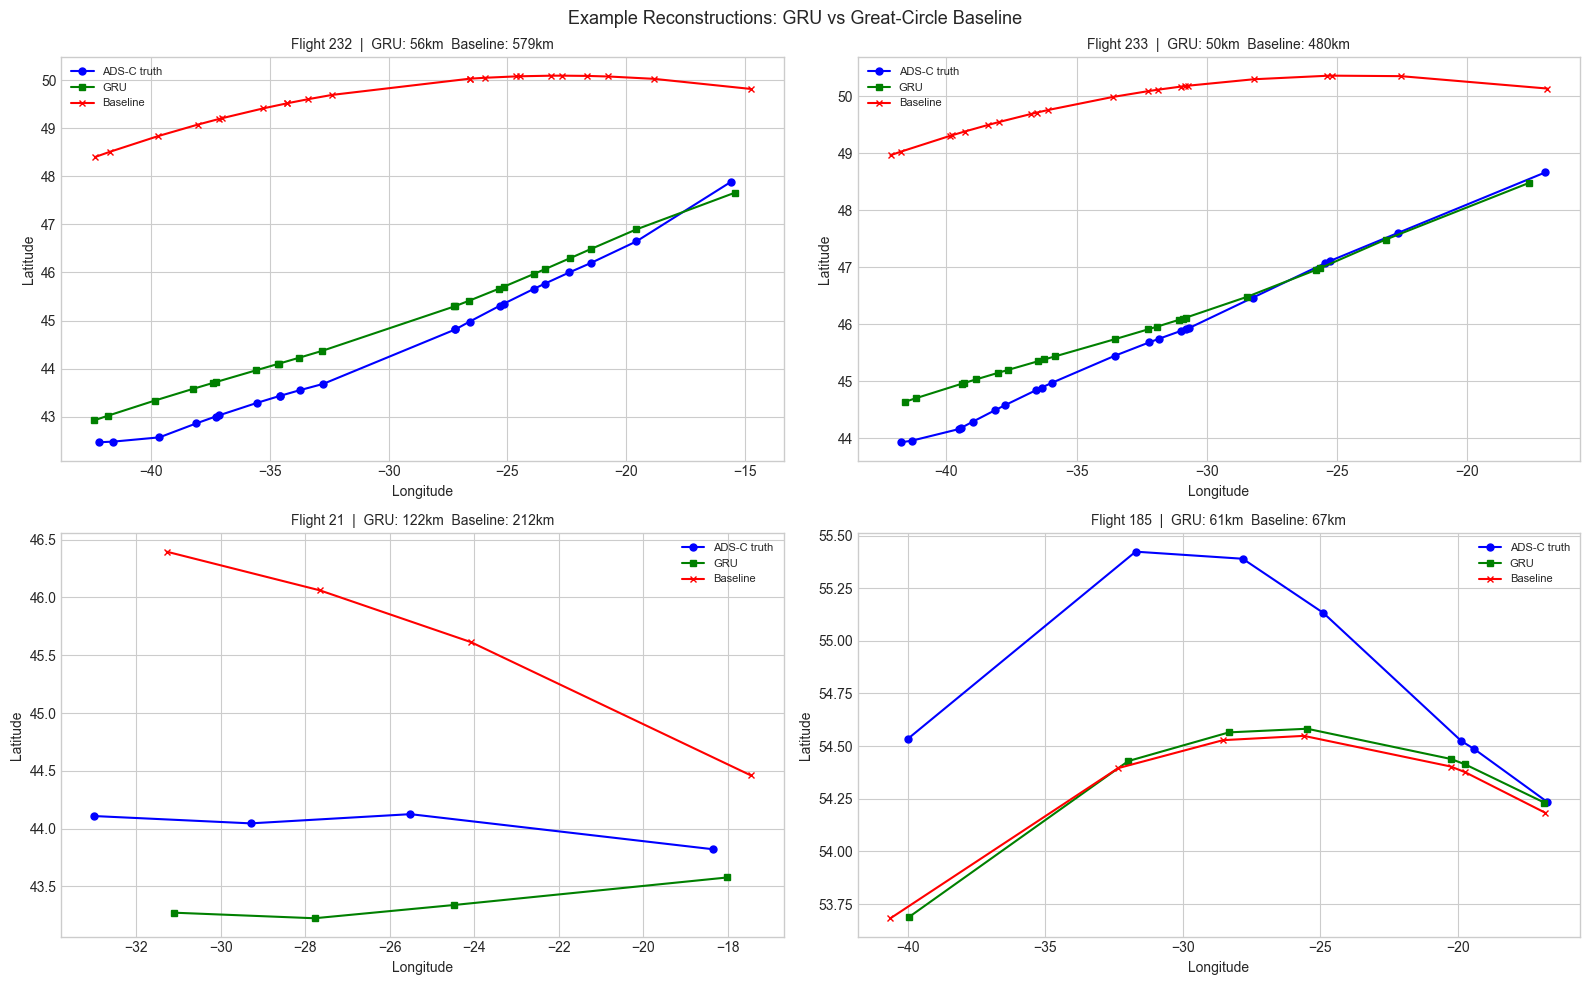

In [6]:
valid_idx = [i for i in range(N) if (mask[i]>0).sum()>=3]
gru_pf_all = np.array([gru_errors[i][mask[i]>0].mean() if (mask[i]>0).sum()>0 else np.inf for i in range(N)])
bl_pf_all  = np.array([baseline_errs[i][mask[i]>0].mean() if (mask[i]>0).sum()>0 else 0   for i in range(N)])
improvements = bl_pf_all - gru_pf_all

top2  = np.argsort(improvements)[-2:][::-1]
rand2 = np.random.default_rng(42).choice(valid_idx, 2, replace=False)
example_idxs = list(top2) + list(rand2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, i in zip(axes, example_idxs):
    m = mask[i] > 0
    if m.sum() == 0: continue
    ax.plot(true_lon[i][m],     true_lat[i][m],     'b-o', ms=5, lw=1.5, label='ADS-C truth')
    ax.plot(pred_lon[i][m],     pred_lat[i][m],     'g-s', ms=5, lw=1.5, label='GRU')
    ax.plot(baseline_lon[i][m], baseline_lat[i][m], 'r-x', ms=5, lw=1.5, label='Baseline')
    ge = gru_errors[i][m].mean()/1e3
    be = baseline_errs[i][m].mean()/1e3
    ax.set_title(f'Flight {i}  |  GRU: {ge:.0f}km  Baseline: {be:.0f}km', fontsize=10)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend(fontsize=8)

plt.suptitle('Example Reconstructions: GRU vs Great-Circle Baseline', fontsize=13)
plt.tight_layout()
plt.savefig(STEP5_ROOT / 'example_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

## Final summary

In [7]:
print('='*55)
print('STEP 5 FINAL RESULTS')
print('='*55)
print(f"Epochs: {len(history_df)}  |  Best: {summary['best_epoch']}  |  Params: {summary['model_params']:,}")
print()
print(f"{'Metric':<25} {'Baseline':>12} {'GRU':>10} {'Improvement':>13}")
print('-'*62)
for label, bv, gv in [
    ('Mean error',   bl_pf.mean()/1e3,           gru_pf.mean()/1e3),
    ('Median error', np.median(bl_pf)/1e3,       np.median(gru_pf)/1e3),
    ('P90 error',    np.percentile(bl_pf,90)/1e3, np.percentile(gru_pf,90)/1e3),
]:
    print(f"  {label:<23} {bv:>10.2f}km {gv:>8.2f}km {(1-gv/bv)*100:>11.1f}%")
print('='*55)

for f in ['training_curves.png','error_comparison.png','example_reconstructions.png','test_summary.json']:
    p = STEP5_ROOT / f
    print(f"  {'OK' if p.exists() else 'MISSING'}: {f}")

STEP 5 FINAL RESULTS
Epochs: 44  |  Best: 29  |  Params: 693,891

Metric                        Baseline        GRU   Improvement
--------------------------------------------------------------
  Mean error                  149.54km    83.37km        44.2%
  Median error                131.04km    65.98km        49.7%
  P90 error                   258.50km   159.19km        38.4%
  OK: training_curves.png
  OK: error_comparison.png
  OK: example_reconstructions.png
  OK: test_summary.json
